# Create Bathymetry NetCDF for Oceananigans ImmersedBoundaryGrid

This notebook creates a NetCDF file with bathymetry data that can be read by the `ImmersedBoundaryGrid` function in FjordsSim.jl.

The NetCDF file must contain:
- `z_faces`: 1D array of **negative** vertical coordinates ordered from minimum (most negative, deepest) to 0 (surface)
- `h`: 2D array of bathymetry depths (**negative values**, 0 for land)
- `lat`: 1D array of latitude centers
- `lon`: 1D array of longitude centers

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.ndimage import label
import rioxarray

## Load Input Data

Load the original bathymetry data from NetCDF or other source

In [2]:
# Load the input NetCDF file
netcdf_path = "Isafjardardjup_topo.nc"
dataset = xr.open_dataset(netcdf_path)
print(dataset)

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 651, x: 641)
Coordinates:
    lonv         (x) float64 5kB ...
    latv         (y) float64 5kB ...
    dlon         float64 8B ...
    dlat         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    depth        (y, x) float64 3MB ...
    depth_fjord  (y, x) float64 3MB ...
    area_km2     (y, x) float64 3MB ...
    lon_grid     (y, x) float64 3MB ...
    lat_grid     (y, x) float64 3MB ...
Attributes:
    stat_summary:  (array([[162.43684104]]), array([[  0],\n       [  1],\n  ...
    sill1_info:    (array([[-23.455 , -23.4766, -23.2316, -23.1811]]), array(...


In [3]:
dataset["depth"]

<xarray.DataArray 'depth' (y: 651, x: 641)> Size: 3MB
[417291 values with dtype=float64]
Coordinates:
    lonv     (x) float64 5kB ...
    latv     (y) float64 5kB ...
    dlon     float64 8B ...
    dlat     float64 8B ...
Dimensions without coordinates: y, x

In [34]:
iy = 420
ix = 50

In [35]:
# Extract bathymetry and coordinates
# Adjust indices as needed for your domain
depth = dataset["depth"][:iy, ix:].values 
lon = dataset["lon_grid"][:iy, ix:].values
lat = dataset["lat_grid"][:iy, ix:].values

print(f"Original shape: {depth.shape}")
print(f"Depth range: {np.nanmin(depth):.1f} to {np.nanmax(depth):.1f} m")

Original shape: (420, 591)
Depth range: 2.0 to 162.4 m


## Process Bathymetry

Handle missing values and remove minor basins

In [36]:
# Replace NaN with 0 (land)
depth = np.where(np.isnan(depth), 0.0, depth)

# Set minimum depth threshold
min_depth = 10.0
depth = np.where((depth > 0) & (depth < min_depth), min_depth, depth)

print(f"After processing: {np.sum(depth > 0)} wet cells, {np.sum(depth == 0)} land cells")

After processing: 53092 wet cells, 195128 land cells


In [37]:
def remove_minor_basins(bathymetry, min_size=1):
    """
    Remove small disconnected water bodies (minor basins).
    Keep only the largest connected water body.
    """
    # Create binary mask of wet cells
    wet_mask = bathymetry > 0
    
    # Label connected components
    labeled, num_features = label(wet_mask)
    
    if num_features == 0:
        return bathymetry
    
    # Find the largest basin
    basin_sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
    largest_basin = np.argmax(basin_sizes) + 1
    
    print(f"Found {num_features} basins. Keeping basin {largest_basin} with {basin_sizes[largest_basin-1]} cells.")
    
    # Keep only the largest basin
    main_basin_mask = labeled == largest_basin
    bathymetry_cleaned = np.where(main_basin_mask, bathymetry, 0.0)
    
    return bathymetry_cleaned

In [38]:
# Remove minor basins
depth = remove_minor_basins(depth, min_size=1)
print(f"After removing minor basins: {np.sum(depth > 0)} wet cells")

Found 1 basins. Keeping basin 1 with 53092 cells.
After removing minor basins: 53092 wet cells


## Visualize Bathymetry

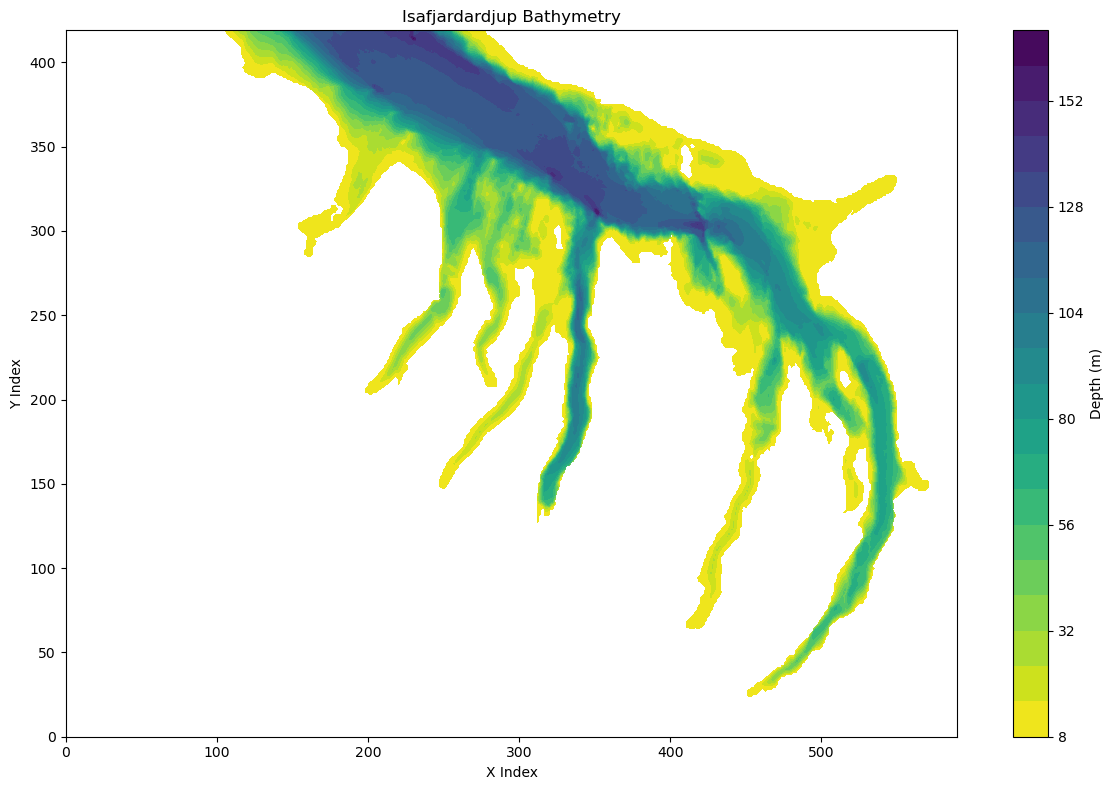

In [39]:
# Plot bathymetry
fig, ax = plt.subplots(figsize=(12, 8))
depth_plot = np.where(depth == 0, np.nan, depth)
im = ax.contourf(depth_plot, levels=20, cmap='viridis_r')
plt.colorbar(im, ax=ax, label='Depth (m)')
ax.set_title('Isafjardardjup Bathymetry')
ax.set_xlabel('X Index')
ax.set_ylabel('Y Index')
plt.tight_layout()
plt.show()

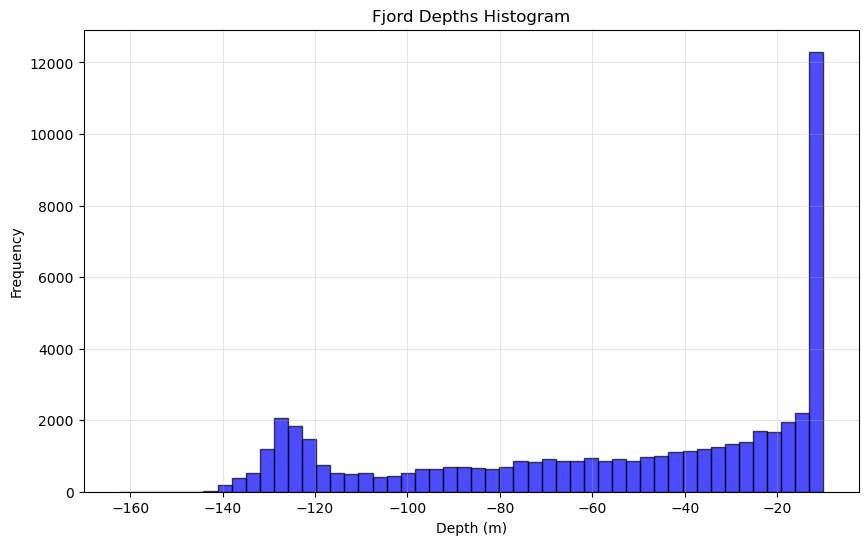

Depth statistics:
  Min: -162.4 m
  Max: -10.0 m
  Mean: -54.6 m
  Median: -41.7 m


In [40]:
# Depth histogram
depth_values = -depth[depth > 0]
plt.figure(figsize=(10, 6))
plt.hist(depth_values, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Fjord Depths Histogram')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Depth statistics:")
print(f"  Min: {depth_values.min():.1f} m")
print(f"  Max: {depth_values.max():.1f} m")
print(f"  Mean: {depth_values.mean():.1f} m")
print(f"  Median: {np.median(depth_values):.1f} m")

## Define Vertical Grid (z_faces)

Define the vertical coordinate faces. These should be **negative** values starting from 0 (surface) going downward.
This follows the Oceananigans convention where z=0 is at the surface and negative values represent depth.

In [41]:
# Define z_faces (negative, ordered from deepest to surface)
# These are layer interfaces (faces)
# Ordered from minimum (most negative) to 0 at surface
z_faces = np.array([
    -190.0,
    -170.0,
    -150.0,
    -140.0,
    -130.0,
    -120.0,
    -110.0,
    -100.0,
    -90.0,
    -80.0,
    -70.0,
    -60.0,
    -50.0,
    -40.0,
    -30.0,
    -25.0,
    -20.0,
    -18.0,
    -16.0,
    -14.0,
    -12.0,
    -10.0,
    -8.0,
    -6.0,
    -5.0,
    -4.0,
    -3.0,
    -2.0,
    -1.0,
    0.0
])

print(f"Number of vertical layers: {len(z_faces) - 1}")
print(f"z_faces range: {z_faces[0]:.1f}m (deepest) to {z_faces[-1]:.1f}m (surface)")
print(f"z_faces: {z_faces}")

Number of vertical layers: 29
z_faces range: -190.0m (deepest) to 0.0m (surface)
z_faces: [-190. -170. -150. -140. -130. -120. -110. -100.  -90.  -80.  -70.  -60.
  -50.  -40.  -30.  -25.  -20.  -18.  -16.  -14.  -12.  -10.   -8.   -6.
   -5.   -4.   -3.   -2.   -1.    0.]


## Optional: Downsample for Coarser Resolution

In [42]:
# Downsample by factor of 2 (optional)
downsample = True

if downsample:
    depth_coarse = -depth[::2, ::2]
    lon_coarse = lon[::2, ::2]
    lat_coarse = lat[::2, ::2]
    print(f"Downsampled shape: {depth_coarse.shape}")
else:
    depth_coarse = -depth
    lon_coarse = lon
    lat_coarse = lat

Downsampled shape: (210, 296)


## Extract 1D Coordinate Arrays

The `grid_from_nc` function expects 1D arrays for lat and lon (cell centers).
If your data has 2D lat/lon grids, extract representative 1D arrays.

In [43]:
# Extract 1D coordinate arrays (cell centers)
# Assuming lat varies with first dimension, lon with second
lat_1d = lat_coarse[:, 0]  # First column (varies with y)
lon_1d = lon_coarse[0, :]  # First row (varies with x)

print(f"Latitude range: {lat_1d.min():.4f} to {lat_1d.max():.4f}")
print(f"Longitude range: {lon_1d.min():.4f} to {lon_1d.max():.4f}")
print(f"Grid size: {len(lat_1d)} x {len(lon_1d)}")

Latitude range: 65.7600 to 66.1780
Longitude range: -23.4800 to -22.3000
Grid size: 210 x 296


## Create NetCDF File

Create the output NetCDF file with the required variables for `grid_from_nc`.

In [44]:
# Create xarray Dataset
# h should be negative (depth below surface)
ds_out = xr.Dataset(
    {
        "h": (["y", "x"], depth_coarse),  # Already negative from downsampling
        "z_faces": (["z"], z_faces),
    },
    coords={
        "lat": (["y"], lat_1d),
        "lon": (["x"], lon_1d),
    },
)

# Add attributes
ds_out["h"].attrs = {
    "long_name": "bathymetry depth",
    "units": "meters",
    "positive": "down",
    "description": "Water depth below surface (negative values, 0 for land)"
}

ds_out["z_faces"].attrs = {
    "long_name": "vertical coordinate faces",
    "units": "meters",
    "positive": "up",
    "description": "Vertical layer interfaces: ordered from deepest (most negative) to surface (0)"
}

ds_out["lat"].attrs = {
    "long_name": "latitude",
    "units": "degrees_north"
}

ds_out["lon"].attrs = {
    "long_name": "longitude",
    "units": "degrees_east"
}

ds_out.attrs = {
    "title": "Isafjardardju Bathymetry for Oceananigans",
    "created": "2025-11-15",
    "description": "Bathymetry data for FjordsSim.jl ImmersedBoundaryGrid function"
}

print(ds_out)

<xarray.Dataset> Size: 502kB
Dimensions:  (y: 210, x: 296, z: 30)
Coordinates:
    lat      (y) float64 2kB 65.76 65.76 65.76 65.77 ... 66.17 66.17 66.18 66.18
    lon      (x) float64 2kB -23.48 -23.48 -23.47 -23.47 ... -22.31 -22.3 -22.3
Dimensions without coordinates: y, x, z
Data variables:
    h        (y, x) float64 497kB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0 -0.0
    z_faces  (z) float64 240B -190.0 -170.0 -150.0 -140.0 ... -3.0 -2.0 -1.0 0.0
Attributes:
    title:        Isafjardardju Bathymetry for Oceananigans
    created:      2025-11-15
    description:  Bathymetry data for FjordsSim.jl ImmersedBoundaryGrid function


In [45]:
# Save to NetCDF
output_file = "C:/Users/fisa/FjordsSim_data/isafjardardjup/Isafjardardjup_bathymetry210x296.nc"
ds_out.to_netcdf(output_file)
print(f"\nBathymetry saved to: {output_file}")


Bathymetry saved to: C:/Users/fisa/FjordsSim_data/isafjardardjup/Isafjardardjup_bathymetry210x296.nc


In [46]:
ds_out

<xarray.Dataset> Size: 502kB
Dimensions:  (y: 210, x: 296, z: 30)
Coordinates:
    lat      (y) float64 2kB 65.76 65.76 65.76 65.77 ... 66.17 66.17 66.18 66.18
    lon      (x) float64 2kB -23.48 -23.48 -23.47 -23.47 ... -22.31 -22.3 -22.3
Dimensions without coordinates: y, x, z
Data variables:
    h        (y, x) float64 497kB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0 -0.0
    z_faces  (z) float64 240B -190.0 -170.0 -150.0 -140.0 ... -3.0 -2.0 -1.0 0.0
Attributes:
    title:        Isafjardardju Bathymetry for Oceananigans
    created:      2025-11-15
    description:  Bathymetry data for FjordsSim.jl ImmersedBoundaryGrid function

## To geotiff for modification

In [52]:
h = ds_out['h']
h = h.assign_coords({
    "x": ds_out["lon"],
    "y": ds_out["lat"],
})

# Attach spatial dims + CRS
h = h.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
h = h.rio.write_crs("EPSG:4326", inplace=False)

# NOW: Reproject onto a clean, regular grid
h2 = h.rio.reproject(
    dst_crs="EPSG:4326",
    resolution=(abs(float(h.x[1]-h.x[0])), abs(float(h.y[1]-h.y[0]))),
    resampling="bilinear"
)

# Write final TIFF (editable)
h2.rio.to_raster("bathy_editable.tif")

In [48]:
ds_out.close()

## Visualize Final Bathymetry with Transect

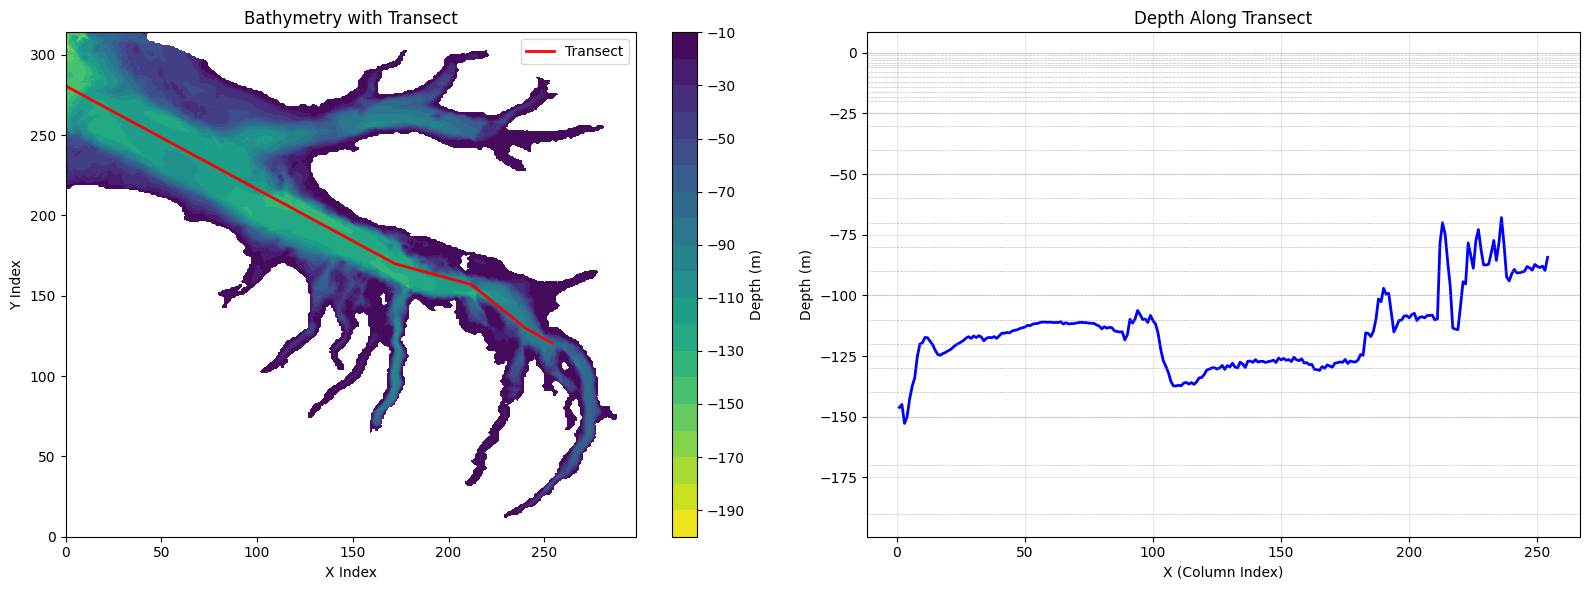

In [22]:
# Define transect line (optional, adjust coordinates as needed)
xs = np.array([1, 172, 212, 240, 255])  # Adjusted for downsampled grid
ys = np.array([280, 170, 157, 130, 120])

# Interpolate transect line
xs_interp = np.arange(1, 255)
interp_line = interp1d(xs, ys, kind='linear')
ys_interp = interp_line(xs_interp)

# Extract depths along transect
depth_transect = []
for x, y in zip(xs_interp, ys_interp):
    xi, yi = int(x), int(y)
    depth_transect.append(depth_coarse[yi, xi])

# Plot bathymetry with transect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bathymetry map
depth_plot = np.where(depth_coarse == 0, np.nan, depth_coarse)
im = ax1.contourf(depth_plot, levels=20, cmap='viridis_r')
ax1.plot(xs_interp, ys_interp, 'r-', linewidth=2, label='Transect')
plt.colorbar(im, ax=ax1, label='Depth (m)')
ax1.set_title('Bathymetry with Transect')
ax1.set_xlabel('X Index')
ax1.set_ylabel('Y Index')
ax1.legend()

# Depth transect
ax2.plot(xs_interp, depth_transect, 'b-', linewidth=2)
for z in z_faces:
    ax2.axhline(y=z, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('X (Column Index)')
ax2.set_ylabel('Depth (m)')
ax2.set_title('Depth Along Transect')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Summary

The NetCDF file has been created with the following structure:
- **h** (2D): Bathymetry depth in meters (negative values for water depth, 0 for land)
- **z_faces** (1D): Vertical coordinate faces (negative values, ordered from deepest to surface: -190m to 0m)
- **lat** (1D): Latitude coordinates (cell centers)
- **lon** (1D): Longitude coordinates (cell centers)

This file can be used with `ImmersedBoundaryGrid(filepath, arch, halo)` in FjordsSim.jl.